# Project XRF maps onto aligned ptychography projections

For each of the three XRF scan angles (**-45, 0, +45 deg**) this notebook:

1. Loads the **Total Fluorescence Yield** map (`NNLS / US_IC`).
2. Loads the **matching aligned ptychography projection** at the same angle from the
   `cfg_fullres` aligned stack (read page-by-page so we never load the full 4.7 GB cube).
3. Brings the XRF onto the projection's pixel grid (scale + sub-pixel shift) by cross-correlating
   a **binary shape-mask of the central object** (the foam) in each modality — so alignment is
   driven by the overall outline, not the (very different) internal contrast.
4. Shows each image on its own, the two **shape masks** used for alignment, then side-by-side +
   overlay so the alignment can be judged.

**Angle correspondence** is handled explicitly: the ptychography angles come from the same
HDF5 the alignment pipeline used (mean-subtracted, indices 19 & 26 dropped), so the projection
we pick is the one physically at -45/0/+45 deg. The XRF is then registered *into that already-aligned
frame*, which is the cross-modality equivalent of "adjusting it the same way" as the projections.

In [13]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import h5py
from skimage.transform import resize as sk_resize
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift as nd_shift, binary_fill_holes, binary_closing, label, gaussian_filter

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

## Configuration

In [14]:
# --- XRF source ---------------------------------------------------------------
XRF_DIR   = "XRF_Data"
XRF_GLOB  = "TIF_32FP/NNLS/US_IC/NNLS-Total_Fluorescence_Yield-cts_s.tif"
# Folder name fragment -> nominal scan angle (deg). Matches bnp_fly****_<tag>.mda.h5
XRF_ANGLE_TAGS = {"_-45": -45.0, "_0": 0.0, "_+45": 45.0}

# --- Aligned ptychography reference (the frame XRF must match) -----------------
REF_STACK = "alignedProjections/APSbeamtime_Oct25/cfg_fullres_aligned_20260514-115952.tif"
# HDF5 the alignment pipeline used (for the angle list), and the indices it dropped.
RAW_HDF5  = "/home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5"
DROP_IDX  = [19, 26]

# --- Scale matching -----------------------------------------------------------
# "pixelsize": use the known pixel sizes below (most accurate).
# "auto":      search for the isotropic scale that maximizes the registration peak.
SCALE_MODE   = "pixelsize"
XRF_PIXEL_NM   = 85.0     # XRF pixel size (nm)
PROJ_PIXEL_NM  = 30.2     # ptychography projection pixel size (nm)
AUTO_SCALE_RANGE = np.linspace(0.5, 1.5, 41)  # multiplies the pixelsize-derived scale

# --- Registration mask --------------------------------------------------------
# Each image is binarized to a mask of the central object (foam = 1, else 0) and the
# two outlines are cross-correlated -- robust across modalities since it ignores
# internal texture. The object is selected by a simple threshold per modality:
XRF_MASK_THRESH  = 500.0   # XRF foam  = pixels  >  this
PROJ_MASK_THRESH = -0.1    # projection foam = pixels  <  this
MASK_SIGMA       = 2.0     # Gaussian softening of the binary mask edges (0 = hard 0/1)
# Horizontal bands of dead/zero pixels split the XRF foam into separate pieces. A vertical
# morphological closing (tall, 1-px-wide footprint) bridges those bands before the
# largest-component step so the whole foam survives (0 disables). XRF only -- projections
# have no bands.
XRF_CLOSE_SIZE   = 25      # footprint height (pixels); set to span the widest dead band

# --- Orientation: XRF assumed already in the same orientation as projections ---
XRF_FLIP_UD = False
XRF_FLIP_LR = False

## Load the ptychography angles and find the matching projection indices

The aligned stack has the same ordering as the alignment pipeline: angles are loaded from
`RAW_HDF5`, indices `DROP_IDX` are removed. We pick, for each XRF angle, the projection whose
angle is closest to it.

In [15]:
with h5py.File(RAW_HDF5, "r") as hf:
    angles_deg = hf["angles"][...].astype(float)          # original degrees
angles_deg = np.delete(angles_deg, DROP_IDX)              # same drop as align.py

# sanity: the reference stack should have this many projections
with tifffile.TiffFile(REF_STACK) as t:
    ref_shape = t.series[0].shape
print(f"Reference stack {os.path.basename(REF_STACK)} -> {ref_shape}")
print(f"angles after drop: {len(angles_deg)}  (range {angles_deg.min():.2f} .. {angles_deg.max():.2f} deg)")
assert ref_shape[0] == len(angles_deg), "stack length != number of angles -- check DROP_IDX/HDF5"

def index_for_angle(target_deg):
    i = int(np.argmin(np.abs(angles_deg - target_deg)))
    return i, angles_deg[i]

proj_index = {}
for tag, ang in XRF_ANGLE_TAGS.items():
    i, actual = index_for_angle(ang)
    proj_index[ang] = i
    print(f"XRF {ang:+5.0f} deg  ->  projection index {i:3d} (actual {actual:+.3f} deg)")

Reference stack cfg_fullres_aligned_20260514-115952.tif -> (556, 585, 1810)
angles after drop: 556  (range -72.00 .. 58.80 deg)
XRF   -45 deg  ->  projection index 115 (actual -44.995 deg)
XRF    +0 deg  ->  projection index 302 (actual +0.004 deg)
XRF   +45 deg  ->  projection index 496 (actual +45.003 deg)


## Load the data

In [16]:
def find_xrf_path(angle_tag):
    hits = sorted(glob.glob(os.path.join(XRF_DIR, f"*{angle_tag}*.mda.h5", XRF_GLOB)))
    if not hits:
        raise FileNotFoundError(f"No XRF tiff for tag '{angle_tag}'")
    return hits[0]

def load_projection(idx):
    # read only the one page we need from the big aligned stack
    return tifffile.imread(REF_STACK, key=idx).astype(np.float32)

xrf_raw, proj_img = {}, {}
for tag, ang in XRF_ANGLE_TAGS.items():
    p = find_xrf_path(tag)
    im = tifffile.imread(p).astype(np.float32)
    if XRF_FLIP_UD: im = im[::-1, :]
    if XRF_FLIP_LR: im = im[:, ::-1]
    xrf_raw[ang]  = im
    proj_img[ang] = load_projection(proj_index[ang])
    print(f"{ang:+5.0f} deg | XRF {im.shape} from {os.path.relpath(p, XRF_DIR)} | proj {proj_img[ang].shape}")

  -45 deg | XRF (236, 648) from bnp_fly1339_-45.mda.h5/TIF_32FP/NNLS/US_IC/NNLS-Total_Fluorescence_Yield-cts_s.tif | proj (585, 1810)
   +0 deg | XRF (236, 648) from bnp_fly1341_0.mda.h5/TIF_32FP/NNLS/US_IC/NNLS-Total_Fluorescence_Yield-cts_s.tif | proj (585, 1810)
  +45 deg | XRF (236, 648) from bnp_fly1336_+45.mda.h5/TIF_32FP/NNLS/US_IC/NNLS-Total_Fluorescence_Yield-cts_s.tif | proj (585, 1810)


## 1. Each XRF map on its own

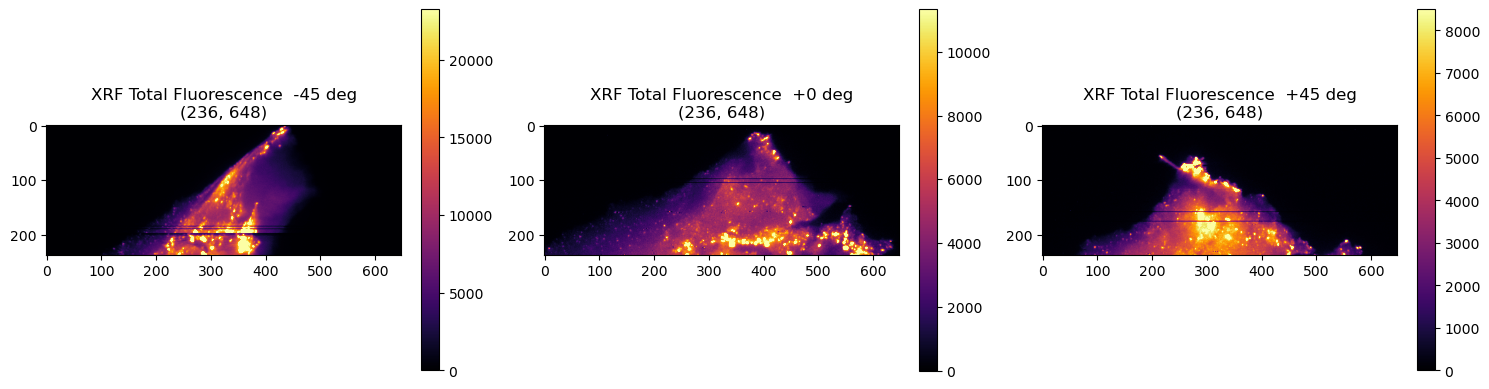

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ang in zip(axes, sorted(xrf_raw)):
    im = xrf_raw[ang]
    m = ax.imshow(im, cmap="inferno",
                  vmin=np.percentile(im, 1), vmax=np.percentile(im, 99))
    ax.set_title(f"XRF Total Fluorescence  {ang:+.0f} deg\n{im.shape}")
    plt.colorbar(m, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 2. Each matching aligned ptychography projection on its own

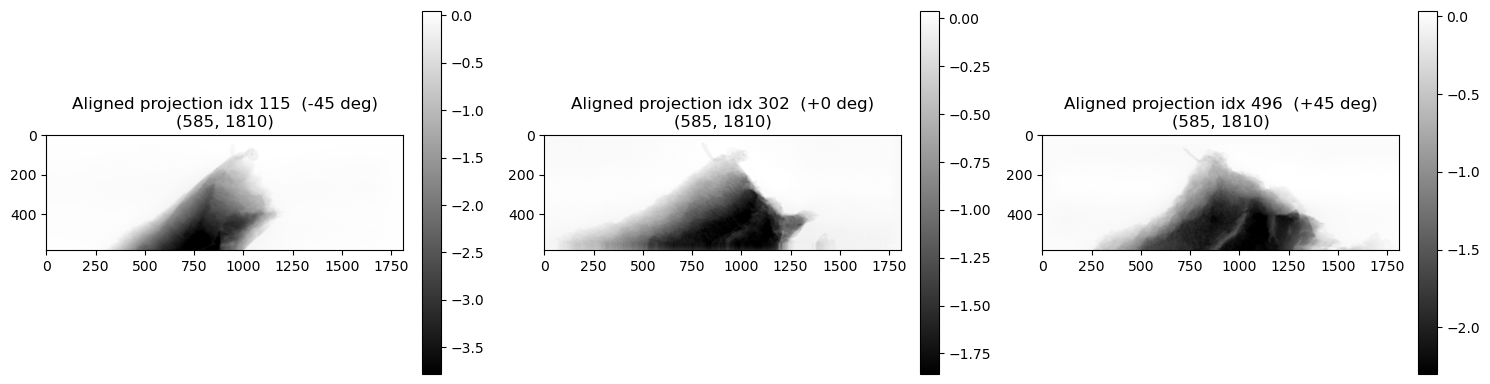

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ang in zip(axes, sorted(proj_img)):
    im = proj_img[ang]
    m = ax.imshow(im, cmap="gray",
                  vmin=np.percentile(im, 1), vmax=np.percentile(im, 99))
    ax.set_title(f"Aligned projection idx {proj_index[ang]}  ({ang:+.0f} deg)\n{im.shape}")
    plt.colorbar(m, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 3. Register each XRF map into the aligned-projection frame

**Scale.** With `SCALE_MODE="pixelsize"` the XRF is resampled by `XRF_PIXEL_NM / PROJ_PIXEL_NM`
(= how many projection pixels one XRF pixel spans) so it lands on the projection's pixel grid.
With `SCALE_MODE="auto"` we additionally sweep a multiplier and keep the scale that gives the
strongest registration peak.

**Shift.** Each image is binarized to a mask of the **central object** (the foam = 1, everything
else = 0). The object is selected by a simple per-modality threshold: XRF pixels `> XRF_MASK_THRESH`
and projection pixels `< PROJ_MASK_THRESH` (phase contrast renders the foam dark). The largest
connected component is kept and its holes filled. `phase_cross_correlation` then matches the two
**outlines** — this ignores internal structure, which is what we want since fluorescence and phase
contrast render the interior completely differently.

The scaled XRF is padded/cropped to the projection size before registration. Section **3a** below
shows the two masks side-by-side *before* the shift is applied, so you can confirm the outlines are
comparable before trusting the cross-correlation.

In [19]:
def fit_into(arr, shape):
    """Center-pad and/or center-crop arr to exactly `shape`."""
    out = np.zeros(shape, dtype=arr.dtype)
    sh = [min(a, b) for a, b in zip(arr.shape, shape)]
    src = [(a - s) // 2 for a, s in zip(arr.shape, sh)]
    dst = [(b - s) // 2 for b, s in zip(shape, sh)]
    out[dst[0]:dst[0]+sh[0], dst[1]:dst[1]+sh[1]] = \
        arr[src[0]:src[0]+sh[0], src[1]:src[1]+sh[1]]
    return out

def scale_xrf(xrf, factor):
    """Resample XRF by `factor` on both axes (factor>1 enlarges)."""
    new_shape = (max(1, round(xrf.shape[0]*factor)), max(1, round(xrf.shape[1]*factor)))
    return sk_resize(xrf, new_shape, order=1, mode="reflect",
                     anti_aliasing=(factor < 1), preserve_range=True).astype(np.float32)

def build_canvas(xrf, proj, factor):
    """Scale the XRF by `factor` and center it on a proj-sized canvas (no shift applied)."""
    return fit_into(scale_xrf(xrf, factor), proj.shape)


def compute_shape_mask(image, thresh, above, mask_sigma=2.0, close_size=0):
    """
    Binarize an image so the central object (the foam) is 1 and everything else is 0,
    so cross-correlation can register on overall *shape* rather than internal structure.

    The object is whichever side of `thresh` it sits on for this modality:
      above=True  -> object = image > thresh   (XRF: foam is bright)
      above=False -> object = image < thresh   (projection: foam is dark phase)

    Horizontal bands of dead/zero pixels (common in XRF) split the object into separate
    connected components. When `close_size > 0` a vertical morphological closing with a
    tall, 1-px-wide footprint of that height bridges the bands (keeping the concave outline)
    before the largest component is selected, so the whole foam survives.

    The largest connected component is then kept and its holes filled, then the edges are
    optionally softened by `mask_sigma`.
    """
    img = np.asarray(image, dtype=np.float32)
    mask = (img > thresh) if above else (img < thresh)

    if close_size and close_size > 0:
        footprint = np.ones((close_size, 1), dtype=bool)   # tall + narrow: bridges horizontal bands only
        mask = binary_closing(mask, structure=footprint)

    labeled, num = label(mask)
    if num == 0:
        return np.zeros_like(img)
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0  # ignore background label
    mask = labeled == sizes.argmax()
    mask = binary_fill_holes(mask)

    mask = mask.astype(np.float32)
    if mask_sigma and mask_sigma > 0:
        mask = gaussian_filter(mask, mask_sigma)
    return mask


def proj_mask(img):
    """Shape mask of the central object in a projection (foam = dark phase)."""
    return compute_shape_mask(img, PROJ_MASK_THRESH, above=False, mask_sigma=MASK_SIGMA)

def xrf_mask(img):
    """Shape mask of the central object in an XRF map (foam = bright). A vertical closing
    bridges the horizontal dead-pixel bands so the foam isn't split into pieces."""
    return compute_shape_mask(img, XRF_MASK_THRESH, above=True, mask_sigma=MASK_SIGMA,
                              close_size=XRF_CLOSE_SIZE)

### 3a. Shape masks used for alignment — compare before registering

Alignment is driven by a binary mask of the central object (foam = 1, everything else = 0)
rather than the raw images, so the two modalities are matched on **overall shape**. The masking
lives in this notebook (`compute_shape_mask` in the helpers cell above) — nothing is imported from
the alignment package.

The object is picked by a simple threshold per modality: XRF pixels `> XRF_MASK_THRESH` and
projection pixels `< PROJ_MASK_THRESH`. For the XRF, thin **horizontal bands of dead/zero pixels**
split the foam into separate pieces, so a vertical morphological closing (`XRF_CLOSE_SIZE`) bridges
those bands before the largest connected component is kept and its holes filled.

The panels below show, for each angle: the **projection mask**, the **XRF mask**, and a
green/magenta overlay. Confirm the threshold caught the whole object and the two outlines are
comparable — if not, adjust `XRF_MASK_THRESH` / `PROJ_MASK_THRESH` / `XRF_CLOSE_SIZE` / `MASK_SIGMA`
(or the scale / flip settings) before trusting the registration below. If the dead bands are still
splitting the foam, raise `XRF_CLOSE_SIZE`.

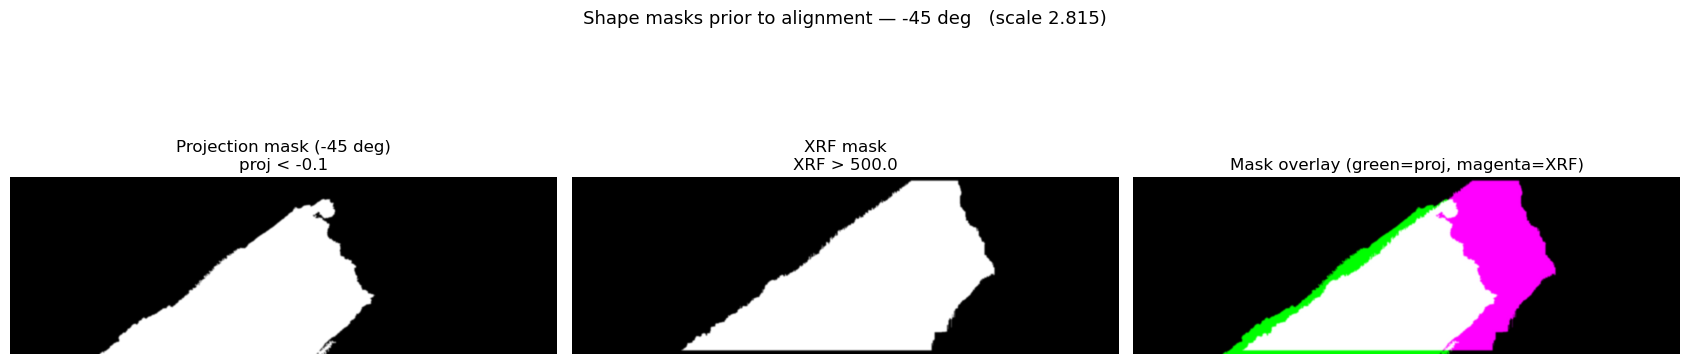

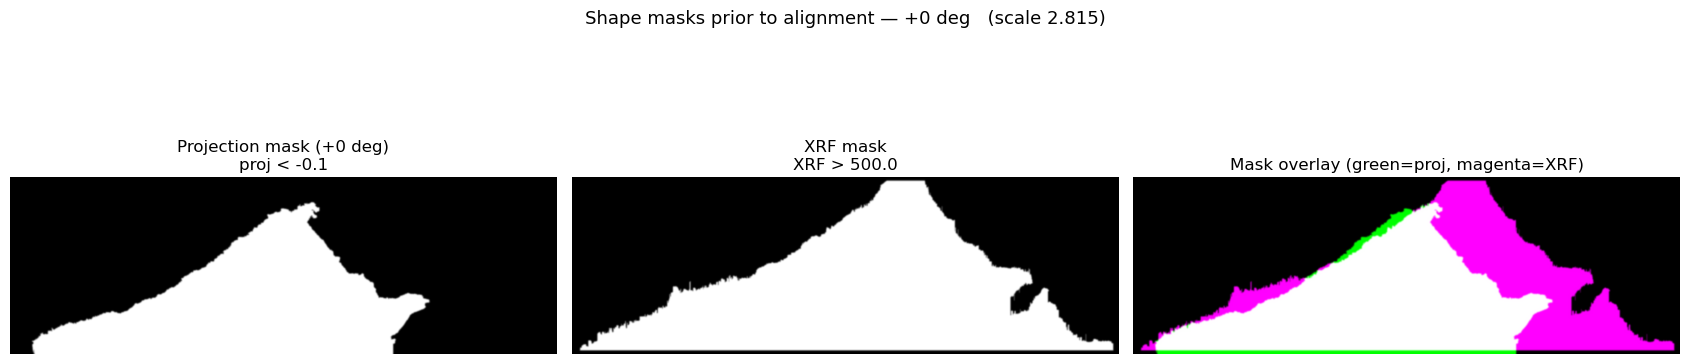

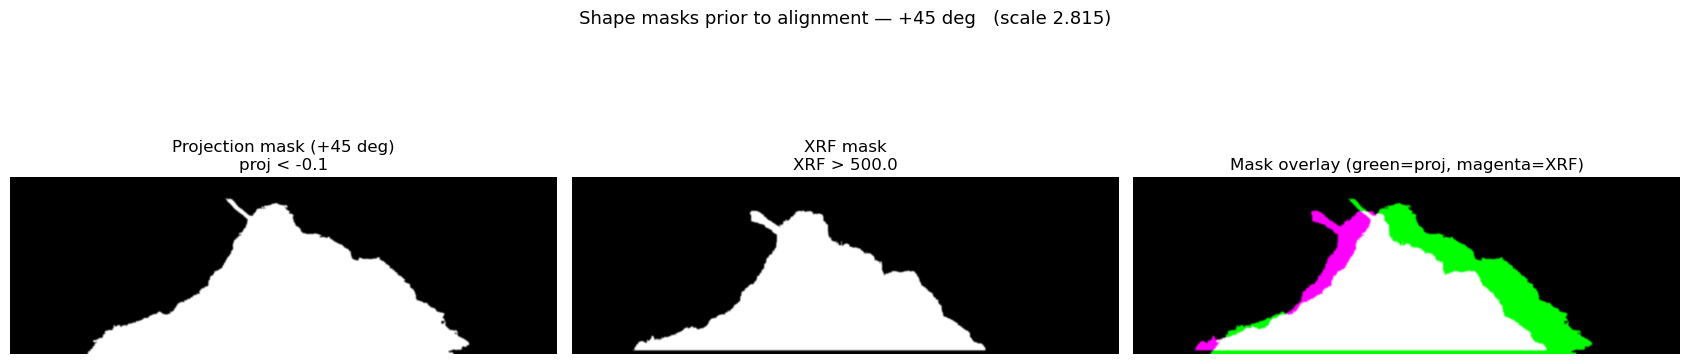

In [20]:
base_factor = XRF_PIXEL_NM / PROJ_PIXEL_NM

# Show the two masks that feed the cross-correlation, BEFORE any shift is applied,
# so we can confirm the projection outline and the (scaled) XRF outline are comparable.
for ang in sorted(xrf_raw):
    proj   = proj_img[ang]
    canvas = build_canvas(xrf_raw[ang], proj, base_factor)   # scaled XRF on proj grid, unshifted
    pmask = proj_mask(proj)
    xmask = xrf_mask(canvas)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    axes[0].imshow(pmask, cmap="gray"); axes[0].set_title(f"Projection mask ({ang:+.0f} deg)\nproj < {PROJ_MASK_THRESH}")
    axes[1].imshow(xmask, cmap="gray"); axes[1].set_title(f"XRF mask\nXRF > {XRF_MASK_THRESH}")

    # overlay: projection=green, XRF=magenta -> grey/white where the outlines coincide
    rgb = np.zeros((*proj.shape, 3))
    rgb[..., 1] = pmask
    rgb[..., 0] = xmask
    rgb[..., 2] = xmask
    axes[2].imshow(rgb); axes[2].set_title("Mask overlay (green=proj, magenta=XRF)")

    for ax in axes: ax.axis("off")
    fig.suptitle(f"Shape masks prior to alignment — {ang:+.0f} deg   (scale {base_factor:.3f})",
                 fontsize=13)
    plt.tight_layout(); plt.show()

In [21]:
def register(xrf, proj, factor):
    """Scale XRF by `factor`, center it on a proj-sized canvas, and phase-correlate the
    two shape masks (projection object vs XRF object).
    Returns (registered_xrf, shift_yx, peak_response)."""
    canvas = build_canvas(xrf, proj, factor)
    pmask = proj_mask(proj)
    shift_yx, _, _ = phase_cross_correlation(
        pmask, xrf_mask(canvas), upsample_factor=10, normalization=None)
    reg = nd_shift(canvas, shift_yx, order=1, mode="constant", cval=0.0)
    # registration quality: normalized cross-correlation of the aligned masks
    a, b = pmask.ravel(), xrf_mask(reg).ravel()
    peak = float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))
    return reg, shift_yx, peak

base_factor = XRF_PIXEL_NM / PROJ_PIXEL_NM
print(f"pixel-size scale factor = {XRF_PIXEL_NM}/{PROJ_PIXEL_NM} = {base_factor:.4f}")

registered, info = {}, {}
for ang in sorted(xrf_raw):
    xrf, proj = xrf_raw[ang], proj_img[ang]
    if SCALE_MODE == "auto":
        best = None
        for mult in AUTO_SCALE_RANGE:
            f = base_factor * mult
            reg, sh, peak = register(xrf, proj, f)
            if best is None or peak > best[3]:
                best = (reg, sh, f, peak)
        reg, sh, f, peak = best
    else:
        f = base_factor
        reg, sh, peak = register(xrf, proj, f)
    registered[ang] = reg
    info[ang] = dict(factor=f, shift=sh, peak=peak)
    print(f"{ang:+5.0f} deg | scale {f:.4f} | shift (dy,dx)=({sh[0]:+.1f},{sh[1]:+.1f}) | "
          f"mask-corr {peak:+.3f}")

pixel-size scale factor = 85.0/30.2 = 2.8146
  -45 deg | scale 2.8146 | shift (dy,dx)=(+17.7,-110.9) | mask-corr +0.861
   +0 deg | scale 2.8146 | shift (dy,dx)=(+15.9,-78.0) | mask-corr +0.818
  +45 deg | scale 2.8146 | shift (dy,dx)=(+7.4,+104.3) | mask-corr +0.870


## 4. Side-by-side and overlay — judge the alignment

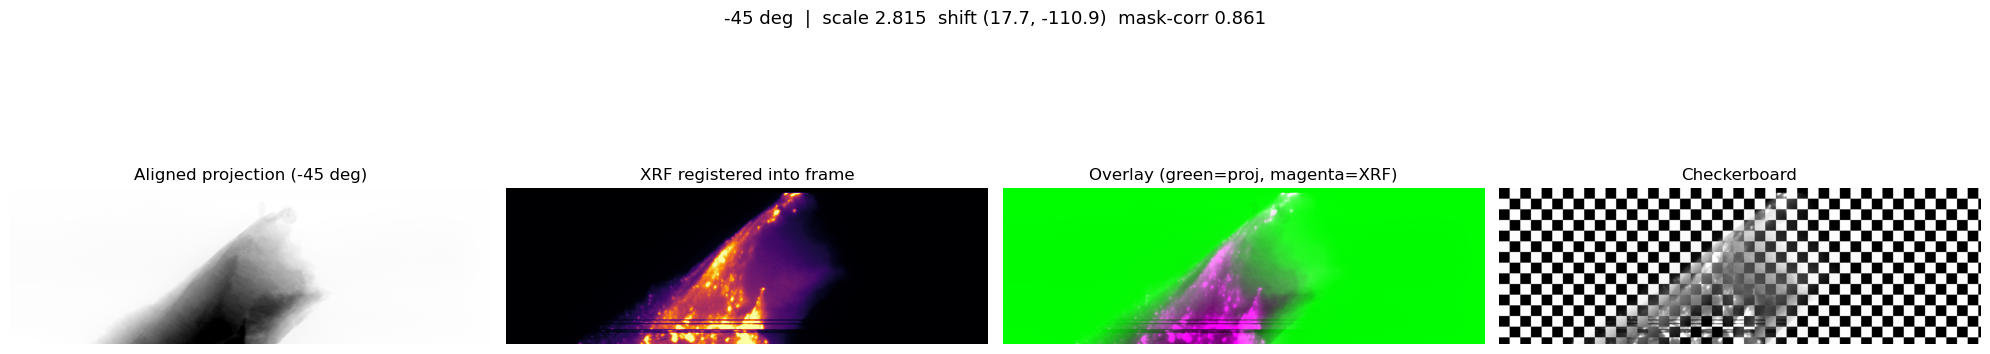

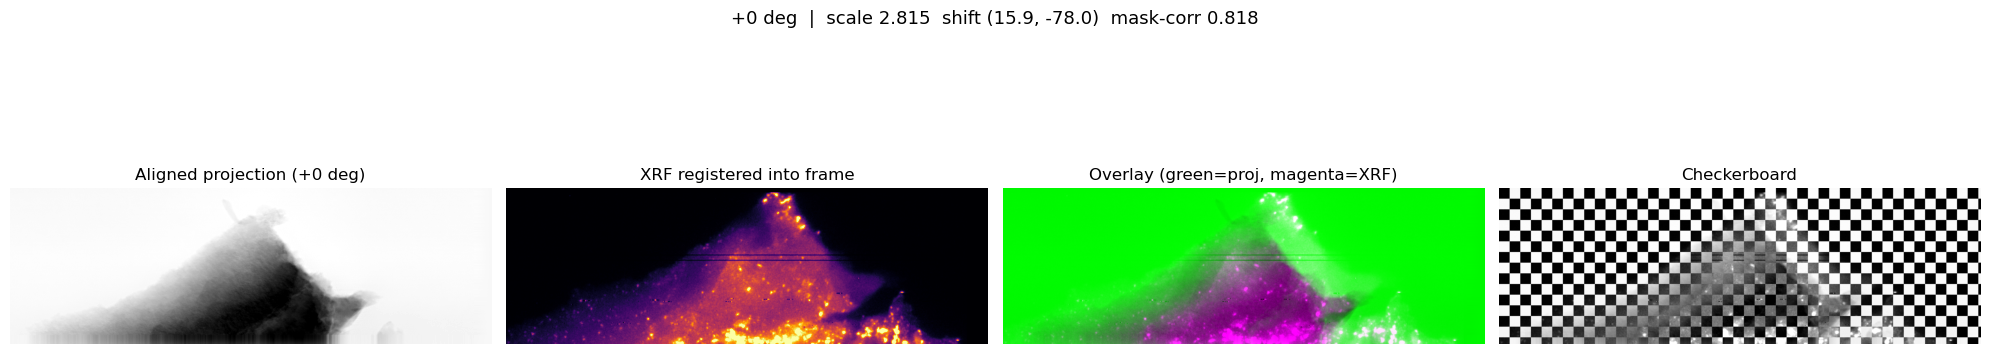

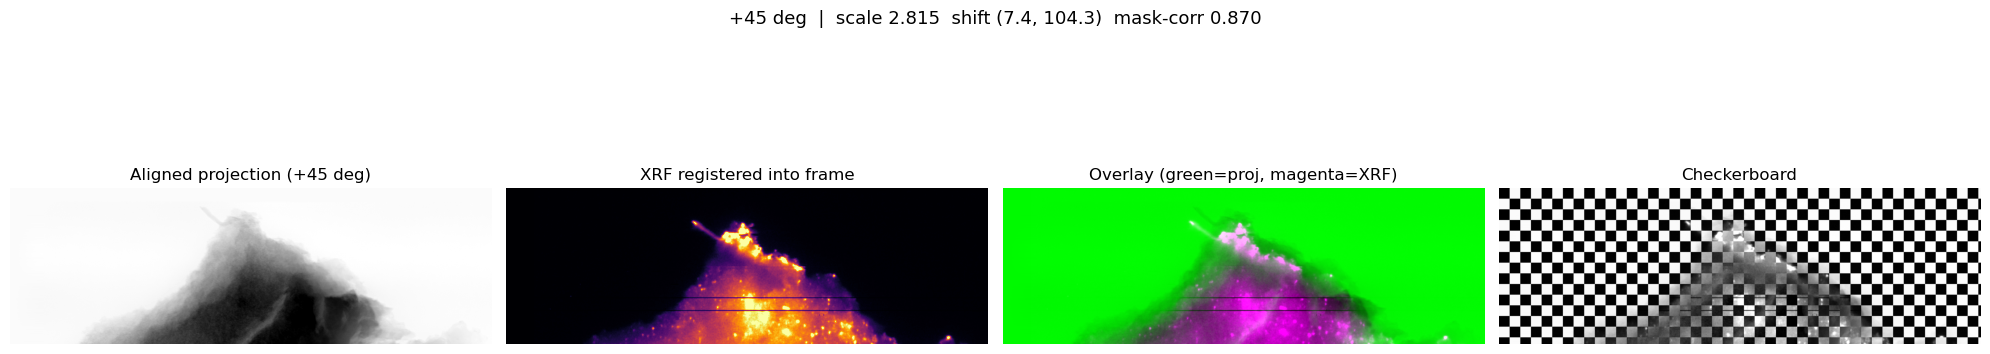

In [22]:
def norm01(img, lo=1, hi=99):
    a, b = np.percentile(img, lo), np.percentile(img, hi)
    return np.clip((img - a) / (b - a + 1e-12), 0, 1)

for ang in sorted(registered):
    proj, reg = proj_img[ang], registered[ang]
    pj, xf = norm01(proj), norm01(reg)
    xf_masked = np.where(reg != 0, xf, np.nan)   # don't tint the padded border

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(pj, cmap="gray"); axes[0].set_title(f"Aligned projection ({ang:+.0f} deg)")
    axes[1].imshow(xf, cmap="inferno"); axes[1].set_title("XRF registered into frame")

    # magenta/green overlay: projection=green, XRF=magenta -> grey where they agree
    rgb = np.zeros((*pj.shape, 3))
    rgb[..., 1] = pj
    rgb[..., 0] = np.nan_to_num(xf_masked)
    rgb[..., 2] = np.nan_to_num(xf_masked)
    axes[2].imshow(rgb); axes[2].set_title("Overlay (green=proj, magenta=XRF)")

    # checkerboard
    cb = pj.copy()
    tile = 40
    yy, xx = np.mgrid[0:pj.shape[0], 0:pj.shape[1]]
    mask = ((yy // tile) + (xx // tile)) % 2 == 0
    cb[mask] = np.nan_to_num(xf_masked)[mask]
    axes[3].imshow(cb, cmap="gray"); axes[3].set_title("Checkerboard")
    for ax in axes: ax.axis("off")
    fig.suptitle(f"{ang:+.0f} deg  |  scale {info[ang]['factor']:.3f}  "
                 f"shift {tuple(np.round(info[ang]['shift'],1))}  "
                 f"mask-corr {info[ang]['peak']:.3f}", fontsize=13)
    plt.tight_layout(); plt.show()

### How to read these panels

- **Overlay:** where the green projection and magenta XRF land on top of each other the region
  turns **grey/white**. Coloured fringes (green on one side, magenta on the other) mean a residual
  shift in that direction.
- **Checkerboard:** features should continue **smoothly across tile boundaries**. Visible
  steps/discontinuities at the seams indicate misalignment.
- **`mask-corr`** (printed above each row) is the normalized cross-correlation of the two shape
  masks in [-1, 1]; higher is better. Compare it between angles to spot a problem scan.

If one angle looks off:
- Check the **section 3a masks** — a bad mask is the most common cause of a bad shift. If the
  threshold caught only the brightest blobs or grabbed background, adjust `XRF_MASK_THRESH` /
  `PROJ_MASK_THRESH`.
- Try `SCALE_MODE = "auto"` to let the scale float around the pixel-size estimate.
- If features look mirrored, set `XRF_FLIP_UD` / `XRF_FLIP_LR` in the config and re-run.
- The fluorescence FOV may only cover part of the projection — that's expected; judge alignment
  on the overlapping region.